# Load libraries

In [56]:
import numpy as np
import itertools, pandas as pd
from models import LinearModel, ChoquetModel
from pymoo_tests import ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2

import matplotlib.pyplot as plt
from utils import evaluate, visualise_weights

# Modelling

In [57]:
# ZDT calling
linear_model = LinearModel(problem = ZDT3(n_dim = 10), max_iter = 10, random_state = 42)
choquet_model = ChoquetModel(problem = ZDT3(n_dim = 10), max_iter = 10, random_state = 42, method = 2)

# DTLZ calling
# linear_model = LinearModel(problem = DTLZ1(n_dim = 10, n_obj = 2), max_iter = 10, random_state = 42)
# choquet_model = ChoquetModel(problem = DTLZ1(n_dim = 10, n_obj = 2), max_iter = 10, random_state = 42, method = 2)

# Let them solve
linear_model.solve()
choquet_model.solve()

# Summary their performance metrics

print(f"LinearModel :  PF {linear_model.PF.shape} PS {linear_model.PS.shape}")
print(f"ChoquetModel:  PF {choquet_model.PF.shape}  PS {choquet_model.PS.shape}")
evaluate([linear_model, choquet_model])

LinearModel :  PF (63, 2) PS (63, 10)
ChoquetModel:  PF (88, 2)  PS (88, 10)


,hypervolume,n_func_eval,n_non_dominated,n_iter,wallclock_time
LinearModel,5.561723,1804,63,10,0.110358
ChoquetModel,5.648835,1793,88,10,0.555912


# Model visualisation

In [58]:
# for kind in ["symmetric", "absolute", "norm"]:
#     visualise_weights(choquet_model, kind = kind);

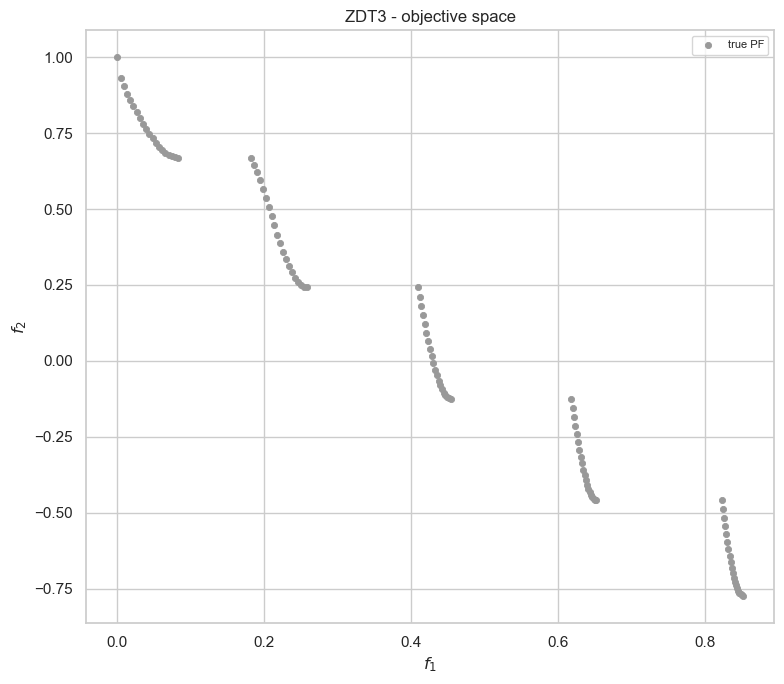

In [59]:
linear_model.visualise("true_pf");

## Linear Model

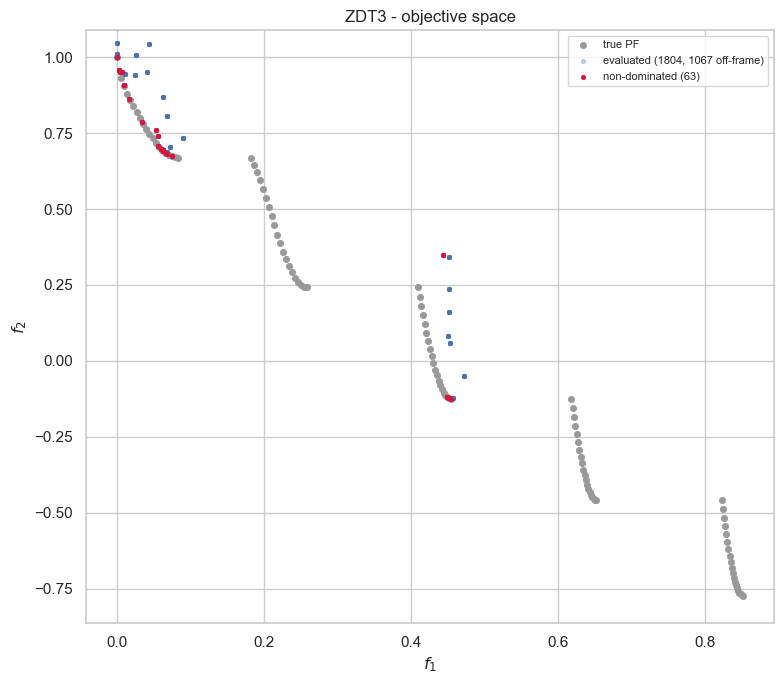

In [61]:
linear_model.visualise("objective");

In [62]:
linear_model.visualise("learning", show = False)

In [63]:
linear_model.visualise("learning", plot_scalarisation = True, show = False)

## Choquet Model

In [64]:
np.all((choquet_model.dec_hist >= 0) & (choquet_model.dec_hist <= 1))

np.True_

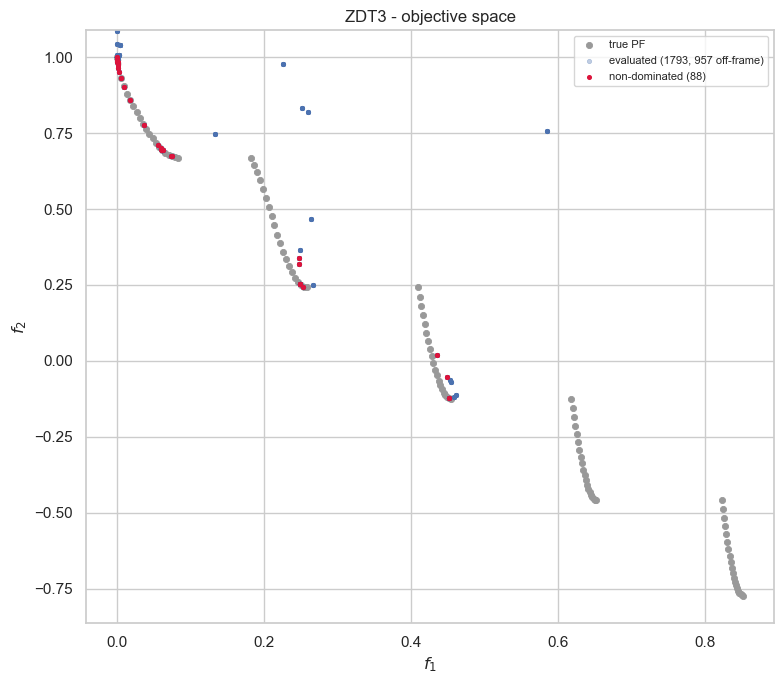

In [65]:
choquet_model.visualise("objective");

In [66]:
choquet_model.visualise("learning", show = False)

In [67]:
choquet_model.visualise("learning", plot_scalarisation = True, show = False)

# Benchmark

Every configuration is solved by both models from the same seed, then scored by `evaluate()` against one shared reference point.

- **ZDT1/2/3** are 2-objective by construction, so they appear once per `n_dim` and ignore `obj_dims`.
- **DTLZ1/2** take `n_obj`, and are skipped when `n_dim <= n_obj` - there would be no tail variables left to carry `g`.
- Hypervolume is comparable **within** a row group only; the reference point differs between configurations, so never compare it across problems or dimensions.

In [ ]:
dec_dims   = [10, 20]
obj_dims   = [2, 3, 4, 5]
max_iter   = 15
model_list = [LinearModel, ChoquetModel]
prob_list  = [ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2]


def build(problem, n_dim, n_obj):
    """This grid cell's problem, or None if the combination does not exist: ZDT is 2-objective by
       construction, and DTLZ needs n_dim > n_obj to leave tail variables to carry g."""
    if problem in (ZDT1, ZDT2, ZDT3):
        return problem(n_dim = n_dim) if n_obj == 2 else None
    return problem(n_dim = n_dim, n_obj = n_obj) if n_dim > n_obj else None


rows = []
for problem, n_dim, n_obj in itertools.product(prob_list, dec_dims, obj_dims):
    prob = build(problem, n_dim, n_obj)
    if prob is None:
        continue

    fitted = [model(problem = prob, max_iter = max_iter, random_state = 42,
                    **(dict(method = 2) if model is ChoquetModel else {}))
              for model in model_list]
    for m in fitted:
        m.solve()

    # evaluate() scores the pair against one shared reference point, and already times each solve
    rows.append(evaluate(fitted).assign(problem = problem.__name__, n_dim = n_dim,
                                        n_obj = prob.n_obj))
    print(problem.__name__, f"n_dim={n_dim}", f"n_obj={prob.n_obj}",
          dict(rows[-1]["wallclock_time"].round(1)))

results = (pd.concat(rows).rename_axis("model").reset_index()
             .set_index(["problem", "n_dim", "n_obj", "model"]).sort_index())
results

ZDT1 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(1.3)}
ZDT1 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.2), 'ChoquetModel': np.float64(1.6)}
ZDT2 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.0), 'ChoquetModel': np.float64(0.3)}
ZDT2 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(0.6)}
ZDT3 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(0.7)}
ZDT3 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.4), 'ChoquetModel': np.float64(1.5)}
DTLZ1 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(1.9)}
DTLZ1 n_dim=10 n_obj=3 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(2.1)}
DTLZ1 n_dim=10 n_obj=4 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(18.5)}
DTLZ1 n_dim=10 n_obj=5 {'LinearModel': np.float64(0.1), 'ChoquetModel': np.float64(6.3)}
DTLZ1 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.2), 'ChoquetModel': np.float64(1.4)}
DTLZ1 n_dim=20 n_obj=3 {'L

hypervolume  n_func_eval  n_non_dominated  \
problem n_dim n_obj model                                                      
DTLZ1   10    2     ChoquetModel  2.028519e+05         2849              174   
                    LinearModel   1.940724e+05         1628               48   
              3     ChoquetModel  4.225253e+07         3289              319   
                    LinearModel   4.069984e+07         1496               66   
              4     ChoquetModel  3.145402e+09         4048              851   
                    LinearModel   2.994291e+09         1584              116   
              5     ChoquetModel  3.192578e+12         3685              579   
                    LinearModel   3.120466e+12         1639              150   
        20    2     ChoquetModel  1.073096e+06         4641               95   
                    LinearModel   1.027082e+06         2961               38   
              3     ChoquetModel  6.087797e+08         8421              530   
                    LinearModel   5.955057e+08         2982               51   
              4     ChoquetModel  9.710679e+11         8883              286   
                    LinearModel   9.420124e+11         3003               72   
              5     ChoquetModel  2.257507e+14         7455               96   
                    LinearModel   2.238174e+14         2898              222   
DTLZ2   10    2     ChoquetModel  2.522116e+00          847               18   
                    LinearModel   2.455639e+00          759               10   
              3     ChoquetModel  7.972459e+00         1111               91   
                    LinearModel   7.926478e+00          781               31   
              4     ChoquetModel  1.119500e+01         1188              143   
                    LinearModel   1.117492e+01          880              120   
              5     ChoquetModel  5.646511e+00         1804              373   
                    LinearModel   5.414587e+00         1012              118   
        20    2     ChoquetModel  8.022998e+00         1491               11   
                    LinearModel   8.005524e+00         1386               10   
              3     ChoquetModel  2.848223e+01          945               11   
                    LinearModel   2.859918e+01         1239               36   
              4     ChoquetModel  8.632643e+01         1680               79   
                    LinearModel   8.641172e+01         1407               66   
              5     ChoquetModel  2.378692e+01          588               24   
                    LinearModel   2.501770e+01          987               62   
ZDT1    10    2     ChoquetModel  5.332650e+00         1727              216   
                    LinearModel   5.327416e+00         1661              228   
        20    2     ChoquetModel  4.766861e+00         3654              236   
                    LinearModel   4.761751e+00         3402              226   
ZDT2    10    2     ChoquetModel  5.154496e+00          484                6   
                    LinearModel   5.229123e+00          550               12   
        20    2     ChoquetModel  5.217661e+00         2184               78   
                    LinearModel   4.971102e+00         1344                4   
ZDT3    10    2     ChoquetModel  5.649172e+00         2101              108   
                    LinearModel   5.651838e+00         2299               79   
        20    2     ChoquetModel  4.878476e+00         4704              157   
                    LinearModel   4.959218e+00         5229              167   

                                  n_iter  wallclock_time  
problem n_dim n_obj model                                 
DTLZ1   10    2     ChoquetModel      15        1.914135  
                    LinearModel       15        0.113058  
              3     ChoquetModel      15        2.078716  
                    LinearModel       15        0.104176  


In [69]:
# hypervolume only compares within a configuration, so pick a winner per row
hv = results["hypervolume"].unstack("model")
hv.assign(winner = hv.idxmax(1), gap_pct = 100 * (hv.max(1) - hv.min(1)) / hv.max(1)).round(4)

model                ChoquetModel   LinearModel        winner  gap_pct
problem n_dim n_obj                                                   
DTLZ1   10    2      2.028519e+05  1.940724e+05  ChoquetModel   4.3280
              3      4.225253e+07  4.069984e+07  ChoquetModel   3.6748
              4      3.145402e+09  2.994291e+09  ChoquetModel   4.8042
              5      3.192578e+12  3.120466e+12  ChoquetModel   2.2587
        20    2      1.073096e+06  1.027082e+06  ChoquetModel   4.2880
              3      6.087797e+08  5.955057e+08  ChoquetModel   2.1804
              4      9.710679e+11  9.420124e+11  ChoquetModel   2.9921
              5      2.257507e+14  2.238174e+14  ChoquetModel   0.8564
DTLZ2   10    2      2.522100e+00  2.455600e+00  ChoquetModel   2.6358
              3      7.972500e+00  7.926500e+00  ChoquetModel   0.5767
              4      1.119500e+01  1.117490e+01  ChoquetModel   0.1794
              5      5.646500e+00  5.414600e+00  ChoquetModel   4.1074
        20    2      8.023000e+00  8.005500e+00  ChoquetModel   0.2178
              3      2.848220e+01  2.859920e+01   LinearModel   0.4089
              4      8.632640e+01  8.641170e+01   LinearModel   0.0987
              5      2.378690e+01  2.501770e+01   LinearModel   4.9196
ZDT1    10    2      5.332600e+00  5.327400e+00  ChoquetModel   0.0981
        20    2      4.766900e+00  4.761800e+00  ChoquetModel   0.1072
ZDT2    10    2      5.154500e+00  5.229100e+00   LinearModel   1.4271
        20    2      5.217700e+00  4.971100e+00  ChoquetModel   4.7255
ZDT3    10    2      5.649200e+00  5.651800e+00   LinearModel   0.0472
        20    2      4.878500e+00  4.959200e+00   LinearModel   1.6281